# 02. 피처 엔지니어링 — 구조화 피처 9개 만들기

> **3주차 작업.** 2주차 EDA에서 파악한 데이터의 *상태*를 바탕으로, 모델에 들어갈 피처 9개를 설계·구현한다.
>
> 작업 흐름:
> 1. **데이터 사전 작성** — 각 컬럼의 의미와 활용 결정을 사전에 정리
> 2. **시간 윈도우 + 라벨 준비** — `launch_date_est + 14일` 컷오프 적용, 라벨된 120개 상품만 추림
> 3. **피처 구현** — groupby + 집계로 9개 피처 생성
> 4. **검증** — NaN 점검, 히트/논히트 그룹 비교
> 5. **저장** — `data/processed/features.parquet`로 저장 (5주차 모델링 입력)

---

## 0. 환경 설정

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# sns.set_theme() 이 rcParams를 리셋하므로 폰트 설정은 반드시 그 뒤에
sns.set_theme(style="whitegrid", palette="muted")
fm.fontManager.addfont("/System/Library/Fonts/AppleSDGothicNeo.ttc")
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

con = duckdb.connect()
con.execute("ATTACH '../data/raw/oliveyoung.db' AS oy (TYPE sqlite)")
print("DuckDB 연결 + SQLite ATTACH 완료")

DuckDB 연결 + SQLite ATTACH 완료


: 

---
## 1. 데이터 사전 (Data Dictionary)

> 이 섹션은 **결정의 기록**이다. 각 컬럼이 무엇을 의미하는지 정의하고, 모델에 어떻게 활용할지(또는 왜 안 쓸지) 사전에 결정한다.
>
> **활용 결정 표기**
> - 🟢 **사용** — 그대로 모델 입력 또는 피처 계산에 활용
> - 🟡 **변형 후 사용** — 누수 점검·단순화·시간 컷오프 적용 등 가공 후 사용
> - 🔴 **사용 금지** — 데이터 누수(미래 정보) 또는 다른 위험으로 제외
> - ⚪ **분석 가치 없음** — 키·메타데이터 등 모델 입력에 부적절

### 1.1 products (200행)

> 상품 메타 정보. 출시 시점에 알 수 있는 *고정 속성* 중심.

| 컬럼 | 타입 | 의미 | 활용 결정 | 근거 |
|---|---|---|---|---|
| `product_id` | TEXT (PK) | 올리브영 상품 고유 ID (URL의 `goodsNo`) | ⚪ | PK, 조인용 |
| `name` | TEXT | 상품명 (예: "토리든 다이브인 저분자 히알루론산 세럼") | ⚪ | 4주차 텍스트 분석은 reviews만 다룸. 상품명은 노이즈 ↑ |
| `brand` | TEXT | 브랜드명 (예: "토리든", "에스트라") | 🟡 | Frequency encoding(브랜드별 데이터셋 등장 횟수)으로 변환. 롱테일 분포(1위도 3.5%, 60%+가 1~2회 등장)라 더미는 차원 폭발·통계 신뢰 부족 |
| `category_main` | TEXT | 대분류 (스킨케어 / 메이크업) | 🟢 | 카테고리별 히트 패턴 차이 가능, 더미로 사용 |
| `category_sub` | TEXT | 소분류 (Breadcrumb 마지막 단계, 예: 베이스메이크업 / 에센스/세럼/앰플) | 🟡 | 6개 그룹으로 통합(베이스/립/아이/에센스/크림/기타스킨케어). 스킨케어 하위 5개 sub는 n<10이라 '기타'로 묶어 통계 신뢰 확보 |
| `price` | INTEGER | 현재 판매가 (할인 적용 후) | 🟡 | `log(price)`로 변환(가격대 right-skewed 분포 보정) + `price_original`과 결합해 할인율 계산. 가격대 축 표현용 |
| `price_original` | INTEGER | 정가 (할인 전 원가). NULL이면 할인 없음 | 🟡 | 할인율 계산용으로만 사용 — `(price_original - price) / price_original`. NULL이면 할인 0% 처리. 다중공선성 회피 위해 모델에 직접 입력 X |
| `launch_date_est` | DATE | 출시일 추정 (= 최초 리뷰일, `MIN(written_at)`) | 🟡 | 모델 직접 입력 X. 컷오프(`launch_date_est + 14일`) 기준으로만 사용 |
| `review_count_total` | INTEGER | 크롤링 시점(2026-04-28) 누적 총 리뷰 수 | 🔴 | **누수** — 미래(=현재) 시점 정보. 14일 컷오프 적용한 `reviews_2wk_count`(피처 #1)로 사용 |
| `rating_avg` | REAL | 크롤링 시점 누적 평균 평점 | 🔴 | **누수** — 미래(=현재) 시점 정보. 14일 컷오프 적용한 `rating_2wk_mean`(피처 #3)로 사용 |
| `url` | TEXT | 상품 상세 페이지 URL | ⚪ | 메타 |
| `crawled_at` | DATETIME | 크롤링 실행 시각 | ⚪ | 메타 |

In [36]:
con.sql("""
SELECT 
  brand, 
  COUNT(*) AS n_products,
  ROUND(100.0 * COUNT(*) / 200, 1) AS pct
FROM oy.products
GROUP BY brand
ORDER BY n_products DESC
LIMIT 20
""").df()

,brand,n_products,pct
0,아누아,7,3.5
1,에스트라,6,3.0
2,클리오,5,2.5
3,바이오힐보,5,2.5
4,페리페라,4,2.0
5,컬러그램,4,2.0
6,헤라,4,2.0
7,투쿨포스쿨,4,2.0
8,에뛰드,4,2.0
9,웨이크메이크,4,2.0


In [37]:
con.sql("""
SELECT 
  category_main,
  category_sub, 
  COUNT(*) AS n_products
FROM oy.products
GROUP BY category_main, category_sub
ORDER BY category_main, n_products DESC
""").df()

,category_main,category_sub,n_products
0,메이크업,베이스메이크업,48
1,메이크업,립메이크업,27
2,메이크업,아이메이크업,25
3,스킨케어,에센스/세럼/앰플,43
4,스킨케어,크림,36
5,스킨케어,스킨/토너,6
6,스킨케어,로션,6
7,스킨케어,미스트/오일,5
8,스킨케어,스킨케어 디바이스,3
9,스킨케어,스킨케어세트,1


### 1.2 reviews (18,695행)

> 시계열 사용자 반응. 시간 컷오프(`launch_date_est + 14일`)를 적용해 초기 2주 데이터만 사용.

| 컬럼 | 타입 | 의미 | 활용 결정 | 근거 |
|---|---|---|---|---|
| `review_id` | TEXT (PK) | 리뷰 고유 ID | ⚪ | PK |
| `product_id` | TEXT (FK) | 상품 FK (products와 조인) | ⚪ | 조인용 |
| `rating` | INTEGER | 별점 (1~5) | 🟡 | 14일 컷오프 적용해 평균(`rating_2wk_mean`) / 분산(`rating_2wk_std`) / 드리프트(`rating_drift`) 계산 |
| `content` | TEXT | 리뷰 본문 텍스트 | 🟡 | 14일 컷오프 적용해 글자 수(`review_length_mean_2wk`) 계산. 4주차 텍스트 분석(BERTopic/감성) 입력으로도 사용 |
| `written_at` | DATE | 리뷰 작성일 | 🟡 | 컷오프(`launch_date_est + 14일`) 필터링 + 일별 카운트로 속도(#1)·기울기(#2)·burst(#8) 계산 |
| `helpful_count` | INTEGER | 그 리뷰가 받은 "도움됐어요" 수 | 🔴 | **누수** — 시점 분리 불가. 크롤링 시점 누적값이라 출시 후 14일 시점 값 추출 불가능. 어떤 가공을 해도 미래 정보가 섞임 |
| `has_photo` | INTEGER | 포토 리뷰 여부 (0/1) | 🟡 | 14일 컷오프 적용해 비율(`photo_review_ratio_2wk`) 계산 |
| `author_id_masked` | TEXT | 작성자 ID 마스킹값 | ⚪ | 메타. 동일 작성자 추적은 이번 분석에서 안 함 |
| `author_skin_type` | TEXT | 작성자 피부타입 코드 (예: "A02"). NULL 34% | 🟡 | NULL은 `'unknown'` 별도 카테고리로 포함. 14일 내 분포의 Shannon 엔트로피로 `skin_type_diversity`(피처 #9) 계산. 'unknown' 비율도 다양성 시그널로 간주 (4주차에 별도 분리 재검토 가능) |
| `crawled_at` | DATETIME | 크롤링 실행 시각 | ⚪ | 메타 |

### 1.3 rankings (200행)

> 라벨 데이터. 현재 카테고리 Top 100 스냅샷 (2026-04-27 기준 1개).

| 컬럼 | 타입 | 의미 | 활용 결정 | 근거 |
|---|---|---|---|---|
| `snapshot_id` | INTEGER (PK) | 스냅샷 row 고유 ID | ⚪ | PK, 메타 |
| `product_id` | TEXT (FK) | 상품 FK (products와 조인) | ⚪ | 조인용 |
| `category` | TEXT | 스냅샷 시점의 카테고리 (스킨케어/메이크업) | ⚪ | `products.category_main`과 동일 정보, 중복 |
| `rank` | INTEGER | 카테고리 내 순위 (1~100) | 🟢 | **라벨 생성 변수**. `is_hit = (rank ≤ 30)`, 31~70위 제외(2주차 결정) |
| `snapshot_date` | DATE | 스냅샷 수집일 (현재 2026-04-27 단일) | ⚪ | 단일 스냅샷이라 변별력 없음. 추후 시계열 스냅샷 추가 시 의미 생김 |

### 1.4 사용 결정 요약

> 위 사전을 정리한 결과, 피처 후보로 삼는 컬럼과 그 이유를 한 곳에 모은다.

**🟢 그대로 사용**
- `category_main` (products) — 카테고리별 히트 패턴 차이, 더미로 사용
- `rank` (rankings) — 라벨 `is_hit` 생성 변수

**🟡 변형 후 사용**
- `brand` (products) — Frequency encoding (브랜드별 등장 횟수)
- `category_sub` (products) — 6 그룹 통합 (메이크업 3 + 에센스/크림/기타스킨케어)
- `price` (products) — `log(price)` 변환 + 할인율 계산용
- `price_original` (products) — 할인율 계산용 (NULL이면 0%)
- `launch_date_est` (products) — `+14일` 컷오프 기준
- `rating` (reviews) — 14일 컷오프 후 평균(#3)/분산(#4)/드리프트(#5)
- `content` (reviews) — 14일 컷오프 후 글자 수(#7), 4주차 텍스트 분석 입력
- `written_at` (reviews) — 컷오프 필터링 + 일별 카운트(#1, #2, #8)
- `has_photo` (reviews) — 14일 내 비율(#6)
- `author_skin_type` (reviews) — 14일 내 엔트로피(#9), NULL은 'unknown'으로 포함

**🔴 사용 금지 (누수 등)**
- `review_count_total` (products) — 크롤링 시점 누적값 = 미래 정보
- `rating_avg` (products) — 크롤링 시점 누적값 = 미래 정보
- `helpful_count` (reviews) — 시점 분리 불가, 가공해도 누수

**⚪ 분석 가치 없음 (메타/중복/PK)**
- products: `product_id`, `name`, `url`, `crawled_at`
- reviews: `review_id`, `product_id`, `author_id_masked`, `crawled_at`
- rankings: `snapshot_id`, `product_id`, `category`, `snapshot_date`

**최종 피처 9개** (2주차 정의 그대로)
1. `reviews_2wk_count` — 출시 후 14일 이내 리뷰 수
2. `reviews_2wk_velocity_slope` — 14일 내 일별 누적 리뷰수의 회귀 기울기
3. `rating_2wk_mean` — 14일 내 평균 평점
4. `rating_2wk_std` — 14일 내 평점 분산
5. `rating_drift` — 평점 드리프트 (정의 재검토: *14일 vs 30일* 또는 *14일 전반 vs 후반*)
6. `photo_review_ratio_2wk` — 14일 내 포토 리뷰 비율
7. `review_length_mean_2wk` — 14일 내 리뷰 평균 글자 수
8. `review_burst_3d` — 출시 후 3일 이내 리뷰 수
9. `skin_type_diversity` — 14일 내 작성자 피부 타입 분포의 엔트로피

**구조화 메타 피처 추가 (위 9개 외)**
- `category_main_dummy` (메이크업 vs 스킨케어)
- `category_sub_group` (6 그룹 더미 5개)
- `brand_freq` (브랜드별 등장 횟수)
- `log_price`
- `discount_rate` (할인율 %, NULL이면 0)

→ 모델 입력 차원 = 피처 9개 + 메타 약 8~9개 = **약 17~18차원**. 학습 표본 120개 대비 표본/차원 ≈ 6.7 — 권장 기준(10) 미달이지만 LightGBM은 견딜 수준. 5주차 로지스틱 회귀에선 정규화(L2) 필수.

---
## 2. 시간 윈도우 + 라벨 데이터 준비

> 라벨 정의(2주차 결정): `is_hit = (rank ≤ 30)`, 31~70위 제외.
> 카테고리별 30:30 → 총 120개 상품.
>
> 각 상품에 `launch_date_est + 14일` 컷오프 추가 → 이후 모든 피처 계산에서 이 컷오프 안의 reviews만 사용.

In [38]:
# products 테이블 구조 확인
con.sql("DESCRIBE oy.products").df()

,column_name,column_type,null,key,default,extra
0,product_id,VARCHAR,YES,PRI,NaN,None
1,name,VARCHAR,NO,NaN,NaN,None
2,brand,VARCHAR,YES,NaN,NaN,None
3,category_main,VARCHAR,YES,NaN,NaN,None
4,category_sub,VARCHAR,YES,NaN,NaN,None
5,price,BIGINT,YES,NaN,NaN,None
6,price_original,BIGINT,YES,NaN,NaN,None
7,launch_date_est,DATE,YES,NaN,NaN,None
8,review_count_total,BIGINT,YES,NaN,NaN,None
9,rating_avg,DOUBLE,YES,NaN,NaN,None


In [39]:
# rankings 테이블 구조 확인
con.sql("DESCRIBE oy.rankings").df()

,column_name,column_type,null,key,default,extra
0,snapshot_id,BIGINT,YES,PRI,None,None
1,product_id,VARCHAR,NO,NaN,None,None
2,category,VARCHAR,NO,NaN,None,None
3,rank,BIGINT,NO,NaN,None,None
4,snapshot_date,DATE,NO,NaN,None,None


In [40]:
# reviews 테이블 구조 확인
con.sql("DESCRIBE oy.reviews").df()

,column_name,column_type,null,key,default,extra
0,review_id,VARCHAR,YES,PRI,NaN,None
1,product_id,VARCHAR,NO,NaN,NaN,None
2,rating,BIGINT,YES,NaN,NaN,None
3,content,VARCHAR,YES,NaN,NaN,None
4,written_at,DATE,YES,NaN,NaN,None
5,helpful_count,BIGINT,YES,NaN,NaN,None
6,has_photo,BIGINT,YES,NaN,NaN,None
7,author_id_masked,VARCHAR,YES,NaN,NaN,None
8,author_skin_type,VARCHAR,YES,NaN,NaN,None
9,crawled_at,TIMESTAMP,YES,NaN,CURRENT_TIMESTAMP,None


In [41]:
label_df = con.sql("""
    SELECT *
    FROM oy.products
""").df()

label_df.head()

,product_id,name,brand,category_main,category_sub,price,price_original,launch_date_est,review_count_total,rating_avg,url,crawled_at
0,A000000012239,[24시간커버지속/올리브영 6년연속 1등] 루나 롱래스팅 팁 컨실러 EX 20colors,루나,메이크업,베이스메이크업,12700,17000,2026-02-25,46017,4.7,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
1,A000000109650,[수채화블러셔] 3CE 무드레시피 페이스 블러쉬 단품/기획,3CE,메이크업,베이스메이크업,16000,20000,2026-02-26,29235,4.8,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
2,A000000117541,[베스트 올인원]우르오스 올인원 200ml 2종 택 1(증정기획/단품),우르오스,스킨케어,로션,22900,29700,2022-07-21,7090,4.8,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
3,A000000120656,[4월 올영픽/스테이셔너리 컬렉션] 투쿨포스쿨 프로타주 펜슬 (메탈홀더 기획/단품),투쿨포스쿨,메이크업,아이메이크업,9900,12000,2026-03-27,83512,4.7,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45
4,A000000121749,킬 래쉬 수퍼프루프 마스카라 1+1 기획,클리오,메이크업,아이메이크업,17400,18000,2025-08-11,57227,4.8,https://www.oliveyoung.co.kr/store/goods/getGo...,2026-04-26 15:49:45


In [42]:
result = con.sql("""
    SELECT 
      p.product_id,
      p.launch_date_est,
      r.rank,
      r.category
    FROM oy.products p
    JOIN oy.rankings r USING (product_id)
    WHERE r.rank <= 30 OR r.rank >= 71

""").df()
print(result.shape)                          # (120, 4)
print(result["rank"].describe())             # min=1, max=100. 단 31~70은 없음
print(result["category"].value_counts())     # 스킨케어 60, 메이크업 60

(120, 4)
count    120.000000
mean      50.500000
std       36.205529
min        1.000000
25%       15.750000
50%       50.500000
75%       85.250000
max      100.000000
Name: rank, dtype: float64
category
색조메이크업    60
스킨케어      60
Name: count, dtype: int64


In [43]:
label_df = con.sql("""
    SELECT 
      p.product_id,
      CASE WHEN r.rank <= 30 THEN 1 ELSE 0 END AS is_hit,
      r.category,
      p.launch_date_est,
      p.launch_date_est + 14 AS cutoff_date
    FROM oy.products p
    JOIN oy.rankings r USING (product_id)
    WHERE r.rank <= 30 OR r.rank >= 71
""").df()

label_df.head()

,product_id,is_hit,category,launch_date_est,cutoff_date
0,A000000109650,0,색조메이크업,2026-02-26,2026-03-12
1,A000000120656,1,색조메이크업,2026-03-27,2026-04-10
2,A000000121749,0,색조메이크업,2025-08-11,2025-08-25
3,A000000137964,1,색조메이크업,2026-03-03,2026-03-17
4,A000000138671,1,색조메이크업,2025-08-12,2025-08-26


In [44]:
print(label_df.shape)                                    # (120, 5)
print(label_df["is_hit"].value_counts())                 # 1=60, 0=60
print(label_df.groupby(["category", "is_hit"]).size())   # 4×30
print(label_df[["launch_date_est", "cutoff_date"]].head(3))  # 14일 차이 확인

(120, 5)
is_hit
0    60
1    60
Name: count, dtype: int64
category  is_hit
색조메이크업    0         30
          1         30
스킨케어      0         30
          1         30
dtype: int64
  launch_date_est cutoff_date
0      2026-02-26  2026-03-12
1      2026-03-27  2026-04-10
2      2025-08-11  2025-08-25


---
## 3. 피처 구현

> **공통 베이스 → 9개 핵심 피처 → 5개 메타 피처** 의 3단 구조.
>
> 핵심 9개는 모두 14일 윈도우 reviews DataFrame(`base_df`) 위에서 `groupby("product_id").agg(...)` 패턴으로 뽑는다. 베이스를 한 번 만들어두면 같은 JOIN+필터를 9번 반복할 필요 없이 깔끔하게 끝난다.
>
> **진행 순서**
> 1. **공통 베이스** — 14일 윈도우 reviews DataFrame
> 2. 첫 피처 같이: `reviews_2wk_count`
> 3. 단순 집계 4개: `rating_mean`, `rating_std`, `photo_ratio`, `length_mean`
> 4. 시계열 2개: `velocity_slope`, `burst_3d`
> 5. 분포 변환 2개: `rating_drift`, `skin_type_diversity`
> 6. 메타 5개: `category` dummy, sub group, `brand_freq`, `log_price`, `discount_rate`

### 3.0 공통 베이스 — 14일 윈도우 reviews DataFrame

**목적:** 핵심 피처 9개가 공통으로 쓸 long format DataFrame을 한 번 만든다.

**입력:** `oy.reviews`, `oy.products` (DuckDB) + `label_df` (메모리)

**출력:** `base_df`
- 한 행 = 한 리뷰
- 120개 상품 × 14일 윈도우 안 리뷰만 포함
- 컬럼: `product_id`, `written_at`, `rating`, `has_photo`, `content`, `author_skin_type`, `days_since_launch`, `review_length`

**결정 사항 (Section 3 진입 시 합의):**
- 상품 스코프: label_df 120개만 (31~70위 제외)
- 도구: DuckDB SQL (한 번에 JOIN + 필터 + 파생 컬럼)
- 미리 넣을 파생 컬럼: `days_since_launch`, `review_length`

In [45]:
# 3.0-1. label_df를 DuckDB가 SQL에서 참조할 수 있게 등록
con.register('label_df', label_df)


# 3.0-2. SQL 쿼리 작성 — 14일 윈도우 베이스 + 중복 리뷰 제거
# 요구사항:
#   ① reviews + products + label_df 3중 JOIN
#   ② WHERE 조건 — written_at이 [launch_date_est, launch_date_est + 14일) 범위
#   ③ SELECT 컬럼 8개: product_id, written_at, rating, has_photo, content,
#       author_skin_type, days_since_launch, review_length
#   ④ QUALIFY로 중복 리뷰 dedupe
#       - 같은 (product_id, written_at, content, author_skin_type) → 첫 1건만 유지
#       - 검증 단계에서 1.2% (26/2231건) 중복 발견했음
#
# 학습 메모:
#   - DATE_DIFF('day', a, b) → b - a (정수, 일 단위)
#   - LENGTH(content) → 글자 수
#   - QUALIFY ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...) = 1
#       PARTITION BY = 그룹화 키 (이 컬럼들이 같으면 한 그룹)
#       ORDER BY    = 그룹 안에서 1, 2, 3, ... 순서 결정 기준
#       = 1         = 그룹당 첫 번째 행만 남김 (= dedupe)

query = """
SELECT 
  r.product_id,
  r.written_at,
  r.rating,
  r.has_photo,
  r.content,
  r.author_skin_type,
  DATE_DIFF('day', p.launch_date_est, r.written_at) AS days_since_launch,
  LENGTH(r.content) AS review_length
FROM oy.reviews r
JOIN oy.products p ON r.product_id = p.product_id
JOIN label_df l ON r.product_id = l.product_id
WHERE r.written_at >= p.launch_date_est 
  AND r.written_at < p.launch_date_est + INTERVAL '14 days'
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY r.product_id, r.written_at, r.content, r.author_skin_type
    ORDER BY r.review_id
) = 1
"""

base_df = con.execute(query).df()
base_df.head()

,product_id,written_at,rating,has_photo,content,author_skin_type,days_since_launch,review_length
0,A000000109650,2026-03-10,5,0,"와, 누드 피치 컬러 진짜 미쳤어요! 바른 듯 안 바른 듯 은은하게 올라오는 발색이...",A03,12,66
1,A000000109650,2026-02-28,5,1,"엄청 고민하고 구매했는데, 색상이 과하지 않고 자연스러워서 좋았어요. 진짜 이쁘네요...",NaN,2,93
2,A000000120656,2026-04-07,5,0,의외로 눈 밑에 애교살로 사용할 때 펄감이 너무 많이보이는 편은 아니라서 데일로 무...,A03,11,59
3,A000000120656,2026-03-27,5,1,누가 이거 지속력으로 깜?ㅋㅋㅋ 그냥 애교살 최강자야 너가,A03,0,32
4,A000000120656,2026-04-03,5,1,애교살에 바르면 예쁠거 같아서 구매했어요!! 추천합니다,A04,7,30


In [46]:
check = con.execute("""
    SELECT r.review_id, r.product_id, r.written_at, r.content
    FROM oy.reviews r
    JOIN label_df l ON r.product_id = l.product_id
    WHERE r.product_id = 'A000000109650'
      AND r.written_at = '2026-03-10'
      AND r.content LIKE '구매 후 아침%'
""").df()
print(check)

  review_id     product_id written_at  \
0  56842011  A000000109650 2026-03-10   
1  56841973  A000000109650 2026-03-10   

                                          content  
0  구매 후 아침 메이크업용으로 썼을때 발색이 많이 과하지 않아 부담스럽지가 않았어요!  
1  구매 후 아침 메이크업용으로 썼을때 발색이 많이 과하지 않아 부담스럽지가 않았어요!  


In [47]:
# 전체에서 중복이 얼마나 있나? (product_id + written_at + content + skin_type 4개로 키)
dup_mask = base_df.duplicated(
    subset=['product_id', 'written_at', 'content', 'author_skin_type'],
    keep=False
)
print(f"중복 그룹에 속한 행: {dup_mask.sum()} / {len(base_df)} ({100*dup_mask.sum()/len(base_df):.1f}%)")

# 어떤 상품에 중복이 몰려 있나?
dup_per_product = (
    base_df[dup_mask]
    .groupby('product_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print("\n중복 행 많은 상위 10개 상품:")
print(dup_per_product)

중복 그룹에 속한 행: 0 / 2217 (0.0%)

중복 행 많은 상위 10개 상품:
Series([], dtype: int64)


In [48]:
# 3.0-3. 검증 — 베이스가 의도대로 만들어졌는지 확인

# ① shape — 14일 윈도우 + dedupe 후 행 수
print(f"shape:    {base_df.shape}")              # (2217, 8) 기대

# ② 상품 수 — 14일 안에 리뷰 0건인 상품이 있으면 120 미만
print(f"상품 수:  {base_df['product_id'].nunique()}")   # 119 (이슈 B: 1개 누락 — 4주차 모델링 직전 결정)

# ③ days_since_launch 범위 — 0 이상 14 미만이어야 함
print("\n=== days_since_launch ===")
print(base_df['days_since_launch'].describe())

# ④ review_length 분포 — 0 이상
print("\n=== review_length ===")
print(base_df['review_length'].describe())

# ⑤ NULL 분포 — author_skin_type 외엔 0이어야
print("\n=== NULL ===")
print(base_df.isna().sum())

# ⑥ 남은 중복 (0이어야) — QUALIFY가 잘 작동했는지 재확인
dup = base_df.duplicated(
    subset=['product_id', 'written_at', 'content', 'author_skin_type'],
    keep=False
).sum()
print(f"\n남은 중복: {dup}")

shape:    (2217, 8)
상품 수:  119

=== days_since_launch ===
count    2217.000000
mean        6.138926
std         4.041706
min         0.000000
25%         2.000000
50%         6.000000
75%        10.000000
max        13.000000
Name: days_since_launch, dtype: float64

=== review_length ===
count    2217.000000
mean      191.889941
std       173.550525
min        28.000000
25%        73.000000
50%       144.000000
75%       244.000000
max      1354.000000
Name: review_length, dtype: float64

=== NULL ===
product_id             0
written_at             0
rating                 0
has_photo              0
content                0
author_skin_type     573
days_since_launch      0
review_length          0
dtype: int64

남은 중복: 0


### 3.1 `reviews_2wk_count` — 출시 후 14일 이내 리뷰 수

- **가설**: 히트일수록 리뷰가 빨리 많이 달릴 것
- **구현 패턴**: `base_df.groupby('product_id').size()` 한 줄 — 이후 8개 피처가 같은 패턴 반복
- **이슈 B 처리**: 14일 안 리뷰 0건인 상품 1개는 NaN → `0`으로 채움 (count는 0이 자연스러움)

In [49]:
# 3.1-1. features DataFrame 시작 — label_df 복사
# (이후 모든 피처는 features에 컬럼으로 추가됨)
features = label_df.copy()

# 3.1-2. 14일 윈도우 내 리뷰 수 카운트
# 패턴 (이후 8개 피처에서 반복):
#   ① base_df.groupby('product_id').집계함수()
#   ② Series 결과를 features에 left merge
#   ③ NaN을 적절한 값으로 채움 (count는 0)
count = base_df.groupby('product_id').size().rename('reviews_2wk_count')
features = features.merge(count, on='product_id', how='left')
features['reviews_2wk_count'] = features['reviews_2wk_count'].fillna(0).astype(int)

# 3.1-3. 즉석 검증
print(f"features shape: {features.shape}")  # (120, 6) 기대

print("\n--- reviews_2wk_count describe ---")
print(features['reviews_2wk_count'].describe())

print("\n--- 히트(1) vs 논히트(0) 비교 ---")
print(features.groupby('is_hit')['reviews_2wk_count'].agg(['mean','median','std','max']).round(1))

print("\n--- 카테고리 × 히트 평균 ---")
print(features.groupby(['category', 'is_hit'])['reviews_2wk_count'].mean().round(1).unstack())

features shape: (120, 6)

--- reviews_2wk_count describe ---
count    120.000000
mean      18.475000
std       19.558558
min        0.000000
25%        5.000000
50%       15.500000
75%       23.250000
max      100.000000
Name: reviews_2wk_count, dtype: float64

--- 히트(1) vs 논히트(0) 비교 ---
        mean  median   std  max
is_hit                         
0       17.1    15.5  17.6   88
1       19.9    15.5  21.4  100

--- 카테고리 × 히트 평균 ---
is_hit       0     1
category            
색조메이크업    18.5  22.4
스킨케어      15.7  17.3


### 3.2 `reviews_2wk_velocity_slope` — 14일 내 일별 리뷰수의 회귀 기울기

- **가설**: 같은 총량이라도 시간 흐름에 따라 가속(+) vs 감속(-) 패턴이 다를 것
  → 단순 `reviews_2wk_count`와 다른 정보 축. 5/09 발견 "분포 형태가 핵심" 가설 검증의 첫 번째 피처.
- **방법**: `days_since_launch`(0~13) ~ daily_count 에 1차 회귀, 기울기 추출
- **0건인 날 처리**: zero-fill (14일 전부 사용 — 후반 0이 늘면 음의 기울기로 잡힘)
- **이슈 B 처리**: 14일 안 리뷰 0건 상품 → base_df에 없어서 groupby에 안 잡힘 → merge 후 자동 NaN
- **해석**: slope > 0 = 입소문 가속, slope < 0 = 초반 거품 후 감속, slope ≈ 0 = 평탄

In [50]:
# 3.2-1. 헬퍼 함수: 한 상품의 일별 리뷰수에서 회귀 기울기 추출
def compute_velocity_slope(group):
    """
    한 상품의 base_df 부분집합 → 14일 일별 리뷰수의 1차 회귀 기울기.

    구현 흐름:
      ① group['days_since_launch'].value_counts() → 일별 카운트 (Series, index=일차)
      ② reindex(range(14), fill_value=0) → 0~13일 전부 채움 (zero-fill)
      ③ np.polyfit(x, y, 1) → [slope, intercept] 반환, [0]번이 slope

    Note: 이슈 B(14일 안 리뷰 0건) 상품은 base_df에 없어서 groupby에 안 잡힘.
    리뷰 1건짜리 상품도 zero-fill 후 14점 → polyfit 작동 (slope ≈ 0 근처가 자연스러움).
    """
    daily = group['days_since_launch'].value_counts().reindex(range(14), fill_value=0)
    return np.polyfit(np.arange(14), daily.values, 1)[0]


# 3.2-2. 적용 + features에 merge (3.1과 같은 패턴)
slope = (
    base_df
    .groupby('product_id')
    .apply(compute_velocity_slope)
    .rename('reviews_2wk_velocity_slope')
)
features = features.merge(slope, on='product_id', how='left')
print(f"features shape: {features.shape}")  # 3.1 직후 실행 시 (120, 7) 기대


# 3.2-3. 즉석 검증
print("\n--- describe ---")
print(features['reviews_2wk_velocity_slope'].describe().round(3))

print(f"\n--- NaN: {features['reviews_2wk_velocity_slope'].isna().sum()}건 (이슈 B 1건 기대) ---")

print("\n--- 히트(1) vs 논히트(0) ---")
print(features.groupby('is_hit')['reviews_2wk_velocity_slope'].agg(['mean', 'median', 'std']).round(3))

m = features.groupby('is_hit')['reviews_2wk_velocity_slope'].mean()
print(f"\n평균 차이 (히트 − 논히트): {(m.loc[1] - m.loc[0]):.4f}")
print("→ 양수면 가설 ✅ (히트가 더 가속), 0 근처면 변별력 약함, 음수면 가설 ❌ (논히트가 더 가속)")

features shape: (120, 7)

--- describe ---
count    119.000
mean      -0.030
std        0.283
min       -1.815
25%       -0.067
50%       -0.029
75%        0.048
max        0.809
Name: reviews_2wk_velocity_slope, dtype: float64

--- NaN: 1건 (이슈 B 1건 기대) ---

--- 히트(1) vs 논히트(0) ---
         mean  median    std
is_hit                      
0      -0.033  -0.031  0.173
1      -0.026  -0.023  0.362

평균 차이 (히트 − 논히트): 0.0073
→ 양수면 가설 ✅ (히트가 더 가속), 0 근처면 변별력 약함, 음수면 가설 ❌ (논히트가 더 가속)


### 3.3 단순 집계 4개 — `rating_mean`, `rating_std`, `photo_ratio`, `length_mean`

같은 `groupby('product_id').agg(...)` 패턴을 **한 번에 4개 묶어서** 처리. (메모리에 합의된 단순 집계 4개)

| 피처 | 집계 함수 | 가설 |
|---|---|---|
| `rating_2wk_mean` | rating.mean() | 히트가 평점 ↑ |
| `rating_2wk_std` | rating.std() | 분산이 시그널일까? (호불호 갈림) |
| `photo_review_ratio_2wk` | has_photo.mean() | 0/1이라 mean = 비율. 히트가 사진 ↑ |
| `review_length_mean_2wk` | review_length.mean() | 히트가 글 길이 ↑ |

**NaN 처리 정책:**
- 14일 안 리뷰 0건 상품 1개(이슈 B): 4개 컬럼 모두 NaN
- 14일 안 리뷰 1건 상품: `rating_std` 만 NaN (분산은 n≥2 필요)
- → 4주차 모델링 직전 일괄 결정 (LightGBM은 NaN 그대로 OK / 로지스틱은 imputation 필요)

In [51]:
# 3.3-1. 단순 집계 4개를 agg() 한 번에
agg_simple = base_df.groupby('product_id').agg(
    rating_2wk_mean        = ('rating', 'mean'),
    rating_2wk_std         = ('rating', 'std'),
    photo_review_ratio_2wk = ('has_photo', 'mean'),
    review_length_mean_2wk = ('review_length', 'mean'),
).reset_index()

# 3.3-2. features에 left merge
features = features.merge(agg_simple, on='product_id', how='left')
print(f"features shape: {features.shape}")  # (120, 10) 기대

# 3.3-3. 검증
cols = ['rating_2wk_mean', 'rating_2wk_std', 'photo_review_ratio_2wk', 'review_length_mean_2wk']

print("\n--- describe ---")
print(features[cols].describe().round(3))

print("\n--- NaN 점검 (이슈 B + std n<2) ---")
print(features[cols].isna().sum())

print("\n--- 히트(1) vs 논히트(0) 평균 ---")
print(features.groupby('is_hit')[cols].mean().round(3))

print("\n--- 차이 (히트 − 논히트) ---")
m = features.groupby('is_hit')[cols].mean()
print((m.loc[1] - m.loc[0]).round(3))

features shape: (120, 11)

--- describe ---
       rating_2wk_mean  rating_2wk_std  photo_review_ratio_2wk  \
count          119.000         108.000                 119.000   
mean             4.736           0.491                   0.836   
std              0.543           0.513                   0.221   
min              1.000           0.000                   0.000   
25%              4.698           0.000                   0.780   
50%              4.889           0.424                   0.895   
75%              5.000           0.757                   1.000   
max              5.000           2.828                   1.000   

       review_length_mean_2wk  
count                 119.000  
mean                  216.306  
std                   135.758  
min                    40.000  
25%                   117.976  
50%                   172.500  
75%                   275.014  
max                   743.667  

--- NaN 점검 (이슈 B + std n<2) ---
rating_2wk_mean            1
rating_2wk_

### 3.5 `rating_drift` — 평점 드리프트 (정의 재검토)

In [52]:
# 3.5-1. 헬퍼 함수: 후반(7~13일) 평점 평균 − 전반(0~6일) 평점 평균
def compute_rating_drift(group):
    """
    한 상품의 base_df 부분집합 → 후반 평점 mean − 전반 평점 mean.

    구현 흐름:
      ① days_since_launch ≤ 6 → 전반 rating Series
      ② days_since_launch ≥ 7 → 후반 rating Series
      ③ 둘 중 한 쪽이라도 0건이면 NaN (계산 불가)
      ④ 둘 다 ≥1건이면 후반.mean() - 전반.mean()

    해석:
      drift > 0 : 후반에 평점 ↑ (입소문 → 점점 좋아짐)
      drift < 0 : 후반에 평점 ↓ (초반 거품 → 식음)
      drift ≈ 0 : 시간 흐름 무관 / 평점 안정
    """
    first_half  = group.loc[group['days_since_launch'] <= 6, 'rating']
    second_half = group.loc[group['days_since_launch'] >= 7, 'rating']
    if len(first_half) == 0 or len(second_half) == 0:
        return np.nan
    return second_half.mean() - first_half.mean()


# 3.5-2. 적용 + features에 merge (3.2·3.8과 동일 패턴)
drift = (
    base_df
    .groupby('product_id')
    .apply(compute_rating_drift)
    .rename('rating_drift')
)
features = features.merge(drift, on='product_id', how='left')
print(f"features shape: {features.shape}")  # (120, 13) 기대


# 3.5-3. 즉석 검증
print("\n--- describe ---")
print(features['rating_drift'].describe().round(3))

print(f"\n--- NaN: {features['rating_drift'].isna().sum()}건")
print("  (이슈 B 1건 + 14일 안 리뷰 1건 11개 + 한 쪽 구간만 채워진 상품)")

print("\n--- 히트(1) vs 논히트(0) ---")
print(features.groupby('is_hit')['rating_drift'].agg(['mean', 'median', 'std']).round(3))

m = features.groupby('is_hit')['rating_drift'].mean()
s = features.groupby('is_hit')['rating_drift'].std()
print(f"\n평균 차이 (히트 − 논히트): {(m.loc[1] - m.loc[0]):.4f}")
print(f"표준편차 비율 (히트 / 논히트): {(s.loc[1] / s.loc[0]):.2f}배")
print("→ 평균이 음수 쪽이면 천장 효과(처음 5점 → 후반 약간 떨어짐), 0 근처면 안정")
print("→ std 비율이 크면 분산 가설(히트는 양극단, 논히트는 안정) 연장선")

features shape: (120, 12)

--- describe ---
count    98.000
mean     -0.041
std       0.521
min      -3.000
25%      -0.108
50%       0.000
75%       0.112
max       1.500
Name: rating_drift, dtype: float64

--- NaN: 22건
  (이슈 B 1건 + 14일 안 리뷰 1건 11개 + 한 쪽 구간만 채워진 상품)

--- 히트(1) vs 논히트(0) ---
         mean  median    std
is_hit                      
0       0.052     0.0  0.335
1      -0.133     0.0  0.648

평균 차이 (히트 − 논히트): -0.1847
표준편차 비율 (히트 / 논히트): 1.94배
→ 평균이 음수 쪽이면 천장 효과(처음 5점 → 후반 약간 떨어짐), 0 근처면 안정
→ std 비율이 크면 분산 가설(히트는 양극단, 논히트는 안정) 연장선


### 3.8 `review_burst_3d` — 14일 내 슬라이딩 3일 윈도우의 최대 리뷰 합

- **가설**: 어느 시점에든 강한 3일 burst가 있는가? (출시 직후 아닐 수도 있음 — 인플루언서 노출 등으로 며칠 후 폭발 가능)
- **방법**: 일별 카운트(zero-fill) → `.rolling(3).sum().max()` 한 줄
- **단순 첫 3일과 차이**: 폭발 시점이 day 0~2가 아니라 day 5~7일 수도. 슬라이딩 max는 시점 무관 피크를 잡음
- **`reviews_2wk_count`와 다른 점**: count는 총량, burst는 피크. 총량 같아도 평탄(매일 ~2건) vs 폭발(3일에 25건 몰림)을 구분
- **분산 가설 검증 2번째 축**: slope와 마찬가지로 평균 차이뿐 아니라 표준편차 차이를 함께 본다 (히트는 분포가 극단적이라는 5/09 가설)

In [53]:
# 3.8-1. 헬퍼 함수: 한 상품의 14일 일별 리뷰수에서 슬라이딩 3일 윈도우 max 추출
def compute_burst_3d(group):
    """
    한 상품의 base_df 부분집합 → 14일 안 슬라이딩 3일 윈도우의 최대 리뷰 합.

    구현 흐름:
      ① group['days_since_launch'].value_counts() → 일별 카운트
      ② reindex(range(14), fill_value=0) → 0~13일 zero-fill
      ③ .rolling(3).sum() → 슬라이딩 3일 합 (앞 2개 index는 NaN)
      ④ .max() → 가장 폭발한 3일 구간의 합

    "출시 직후"가 아니라 "14일 안 어느 시점에든 가장 강한 3일 burst"를 잡음.
    """
    daily = group['days_since_launch'].value_counts().reindex(range(14), fill_value=0)
    return daily.rolling(3).sum().max()


# 3.8-2. 적용 + features에 merge (3.1·3.2와 같은 패턴)
burst = (
    base_df
    .groupby('product_id')
    .apply(compute_burst_3d)
    .rename('review_burst_3d')
)
features = features.merge(burst, on='product_id', how='left')
print(f"features shape: {features.shape}")  # 3.2 직후 실행 시 (120, 8) 기대


# 3.8-3. 즉석 검증
print("\n--- describe ---")
print(features['review_burst_3d'].describe().round(2))

print(f"\n--- NaN: {features['review_burst_3d'].isna().sum()}건 (이슈 B 1건 기대) ---")

print("\n--- 히트(1) vs 논히트(0) ---")
print(features.groupby('is_hit')['review_burst_3d'].agg(['mean', 'median', 'std']).round(2))

m = features.groupby('is_hit')['review_burst_3d'].mean()
s = features.groupby('is_hit')['review_burst_3d'].std()
print(f"\n평균 차이 (히트 − 논히트): {(m.loc[1] - m.loc[0]):.2f}")
print(f"표준편차 비율 (히트 / 논히트): {(s.loc[1] / s.loc[0]):.2f}배")
print("→ 평균 차이 + std 비율 둘 다 크면 분산 가설 ✅✅, 평균만 차이나면 단순 양 시그널")

features shape: (120, 13)

--- describe ---
count    119.00
mean       8.87
std       11.10
min        1.00
25%        3.00
50%        6.00
75%       10.00
max       76.00
Name: review_burst_3d, dtype: float64

--- NaN: 1건 (이슈 B 1건 기대) ---

--- 히트(1) vs 논히트(0) ---
        mean  median    std
is_hit                     
0       8.15     7.0   8.29
1       9.57     6.0  13.34

평균 차이 (히트 − 논히트): 1.41
표준편차 비율 (히트 / 논히트): 1.61배
→ 평균 차이 + std 비율 둘 다 크면 분산 가설 ✅✅, 평균만 차이나면 단순 양 시그널


### 3.9 `skin_type_diversity` — 작성자 피부 타입 다양성 (엔트로피)

In [54]:
# 3.9-1. 헬퍼 함수: 한 상품의 author_skin_type 분포 → Shannon entropy (log2)
def compute_skin_type_diversity(group):
    """
    한 상품의 base_df 부분집합 → 14일 안 작성자 피부타입 Shannon entropy (bits).

    구현 흐름:
      ① group['author_skin_type'].fillna('unknown').value_counts() → 타입별 빈도
      ② 확률로 정규화: p_i = n_i / N
      ③ H = -Σ p_i * log2(p_i)

    해석:
      H = 0   : 한 종류 피부타입에 쏠림 (예: unknown만 잔뜩)
      H 큼    : 여러 피부타입이 고루 등장 → 폭넓은 시장성 가설
      단위는 bits (log2 사용 — 정보이론 표준, "X비트 다양성" 직관적)

    NULL 처리:
      'unknown'을 별도 카테고리로 보존 (Section 1 결정).
      → "어떤 사람이 썼는지 모름"도 분포의 한 축으로 본다.

    엣지 케이스:
      0건  → groupby 결과 없음 → merge 후 NaN (이슈 B 1건 기대)
      1건  → H = 0 (-1*log2(1) = 0, 한 종류만 등장)
    """
    counts = group['author_skin_type'].fillna('unknown').value_counts()
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))


# 3.9-2. 적용 + features에 merge (3.5·3.8과 동일 패턴)
#         + 보조 컬럼 skin_type_n_unique (등장한 고유 타입 수)
diversity = (
    base_df
    .groupby('product_id')
    .apply(compute_skin_type_diversity)
    .rename('skin_type_diversity')
)
n_unique = (
    base_df
    .groupby('product_id')['author_skin_type']
    .apply(lambda s: s.fillna('unknown').nunique())
    .rename('skin_type_n_unique')
)
features = features.merge(diversity, on='product_id', how='left')
features = features.merge(n_unique,  on='product_id', how='left')
print(f"features shape: {features.shape}")  # (120, 15) 기대


# 3.9-3. 즉석 검증
print("\n--- describe (skin_type_diversity, bits) ---")
print(features['skin_type_diversity'].describe().round(3))

print("\n--- describe (skin_type_n_unique) ---")
print(features['skin_type_n_unique'].describe().round(2))

print(f"\n--- NaN: diversity {features['skin_type_diversity'].isna().sum()}건, "
      f"n_unique {features['skin_type_n_unique'].isna().sum()}건 (이슈 B 1건 기대) ---")

print("\n--- 히트(1) vs 논히트(0) — skin_type_diversity ---")
print(features.groupby('is_hit')['skin_type_diversity'].agg(['mean', 'median', 'std']).round(3))

print("\n--- 히트(1) vs 논히트(0) — skin_type_n_unique ---")
print(features.groupby('is_hit')['skin_type_n_unique'].agg(['mean', 'median', 'std']).round(2))

m = features.groupby('is_hit')['skin_type_diversity'].mean()
s = features.groupby('is_hit')['skin_type_diversity'].std()
print(f"\n[diversity] 평균 차이 (히트 − 논히트): {(m.loc[1] - m.loc[0]):.3f}")
print(f"[diversity] 표준편차 비율 (히트 / 논히트): {(s.loc[1] / s.loc[0]):.2f}배")
print("→ 평균 차이 + 비율 둘 다 크면 분산 가설 5번째 검증, 평균만 차이나면 단순 양 시그널")


features shape: (120, 15)

--- describe (skin_type_diversity, bits) ---
count    119.000
mean       1.678
std        0.775
min       -0.000
25%        1.450
50%        1.918
75%        2.218
max        2.709
Name: skin_type_diversity, dtype: float64

--- describe (skin_type_n_unique) ---
count    119.00
mean       4.44
std        2.01
min        1.00
25%        3.00
50%        5.00
75%        6.00
max        8.00
Name: skin_type_n_unique, dtype: float64

--- NaN: diversity 1건, n_unique 1건 (이슈 B 1건 기대) ---

--- 히트(1) vs 논히트(0) — skin_type_diversity ---
         mean  median    std
is_hit                      
0       1.709   1.922  0.765
1       1.646   1.907  0.790

--- 히트(1) vs 논히트(0) — skin_type_n_unique ---
        mean  median   std
is_hit                    
0       4.49     5.0  2.04
1       4.38     5.0  1.99

[diversity] 평균 차이 (히트 − 논히트): -0.063
[diversity] 표준편차 비율 (히트 / 논히트): 1.03배
→ 평균 차이 + 비율 둘 다 크면 분산 가설 5번째 검증, 평균만 차이나면 단순 양 시그널


### 3.10 메타 피처 5개 — 상품 자체 속성

핵심 피처 9개(리뷰·평점 시계열·텍스트 분포)와 별개로, **상품 자체의 정적 속성**을 모델 입력으로 추가.

| # | 피처 | 정의 |
|---|---|---|
| 1 | `is_makeup` | `products.category_main == '메이크업'` → 1 / '스킨케어' → 0 (B안, 2026-05-14 결정) |
| 2 | `category_sub_group` | `category_sub`를 6 그룹으로 통합 (메이크업 3 + 에센스/크림/기타스킨케어). 더미 5개 |
| 3 | `brand_freq` | brand 등장 빈도 (Frequency encoding, 롱테일 분포 대응) |
| 4 | `log_price` | `np.log1p(price)` (왜도 보정) |
| 5 | `discount_rate` | `(price_original - price) / price_original * 100`, `price_original` NULL이면 0% |

출처는 전부 `products` 테이블 (Section 1.4 결정). label_df의 120개 상품에 맞춰 merge.


#### 3.10.0 사전 — products 메타 5컬럼을 features에 merge

이후 3.10.1~5에서 반복해서 products를 쿼리하지 않도록, 메타 원본 5컬럼을 한 번에 features에 붙여둠.

| 컬럼 | 용도 |
|---|---|
| `category_main` | 3.10.1 → is_makeup |
| `category_sub` | 3.10.2 → category_sub_group + 더미 5개 |
| `brand` | 3.10.3 → brand_freq |
| `price` | 3.10.4 → log_price |
| `price_original` | 3.10.5 → discount_rate (NULL이면 0%) |

원본 컬럼은 검증·디버깅용으로 features에 유지, 4주차 모델 학습 직전에 한 번에 drop.


In [55]:
# 3.10.0-1. products 메타 5컬럼 조회 → features에 left merge

meta_df = con.execute("""
    SELECT product_id, category_main, category_sub,
           brand, price, price_original
    FROM oy.products
""").df()

features = features.merge(meta_df, on='product_id', how='left')


# 3.10.0-2. 검증 — shape + NULL 분포
print(f"features.shape: {features.shape}     # (120, 20) 기대")
print()
print("=== NULL 분포 (메타 5컬럼) ===")
print(features[['category_main','category_sub','brand','price','price_original']].isna().sum())
print()
print("→ price_original만 NULL 있어야 정상 (할인 정보 없는 상품 = 정가 판매)")
print("  나머지 4컬럼이 NULL이면 1주차 수집 누락 — 점검 필요")


features.shape: (120, 20)     # (120, 20) 기대

=== NULL 분포 (메타 5컬럼) ===
category_main     0
category_sub      0
brand             0
price             0
price_original    6
dtype: int64

→ price_original만 NULL 있어야 정상 (할인 정보 없는 상품 = 정가 판매)
  나머지 4컬럼이 NULL이면 1주차 수집 누락 — 점검 필요


#### 3.10.1 `is_makeup` — category_main 더미

`products.category_main`을 사용 (B안). 메이크업 100건 / 스킨케어 100건 = 완벽 50:50이라 더미 1개로 충분 (`drop_first=True` 효과).

> 참고: `rankings.category`는 '색조메이크업'/'스킨케어'로 라벨이 달랐지만 행 단위로 100% 동일 의미. 메타 5개 출처 일관성을 위해 `products` 한 곳에서 끌어옴.


In [56]:
# 3.10.1-1. is_makeup 생성 — products.category_main 사용 (B안, 2026-05-14 결정)

features['is_makeup'] = (features['category_main'] == '메이크업').astype(int)


# 3.10.1-2. 검증 — is_makeup 분포 + is_hit 교차표
print("=== is_makeup 분포 ===")
print(features['is_makeup'].value_counts())
print()
print("=== category_main × is_hit 교차표 (라벨 균형 재확인) ===")
print(pd.crosstab(features['category_main'], features['is_hit']))


=== is_makeup 분포 ===
is_makeup
1    60
0    60
Name: count, dtype: int64

=== category_main × is_hit 교차표 (라벨 균형 재확인) ===
is_hit          0   1
category_main        
메이크업           30  30
스킨케어           30  30


#### 3.10.2 `category_sub_group` — category_sub 6 그룹 통합 → 더미 5개

Section 1.4 결정: 메이크업 3개 + 스킨케어 큰 2개(에센스/크림) + 스킨케어 n<10인 나머지를 '기타스킨케어'로 묶어 **6 그룹**.

| 원본 (예시) | 통합 그룹 |
|---|---|
| 베이스메이크업 | 베이스메이크업 |
| 아이메이크업 | 아이메이크업 |
| 립메이크업 | 립메이크업 |
| 에센스 | 에센스 |
| 크림 | 크림 |
| 토너/미스트/페이스오일 등 (n<10) | 기타스킨케어 |

`pd.get_dummies(..., drop_first=True)`로 더미 5개. baseline 그룹은 알파벳/지정 기준으로 정해짐.


In [57]:
# 3.10.2-1. category_sub 실제 분포 확인 (label_df 120개 기준)

print("=== category_sub 전체 분포 ===")
print(features['category_sub'].value_counts(dropna=False))
print()
print("=== category_main별 category_sub 분포 ===")
print(features.groupby('category_main')['category_sub'].value_counts())


=== category_sub 전체 분포 ===
category_sub
베이스메이크업      33
크림           25
에센스/세럼/앰플    23
아이메이크업       14
립메이크업        13
로션            4
미스트/오일        3
스킨/토너         2
스킨케어 디바이스     2
스킨케어세트        1
Name: count, dtype: int64

=== category_main별 category_sub 분포 ===
category_main  category_sub
메이크업           베이스메이크업         33
               아이메이크업          14
               립메이크업           13
스킨케어           크림              25
               에센스/세럼/앰플       23
               로션               4
               미스트/오일           3
               스킨/토너            2
               스킨케어 디바이스        2
               스킨케어세트           1
Name: count, dtype: int64


In [58]:
# 3.10.2-2. category_sub_group 매핑 + 더미 5개 생성

# ① 매핑 dict — 메이크업 3개 + 스킨케어 큰 2개는 그대로, 스킨케어 n<10 5개는 '기타스킨케어'로 통합
group_map = {
    '베이스메이크업':   '베이스메이크업',
    '아이메이크업':     '아이메이크업',
    '립메이크업':       '립메이크업',
    '크림':             '크림',
    '에센스/세럼/앰플': '에센스/세럼/앰플',
    # 아래 5개 → '기타스킨케어' (n<10 기준)
    '로션':             '기타스킨케어',
    '미스트/오일':      '기타스킨케어',
    '스킨/토너':        '기타스킨케어',
    '스킨케어 디바이스': '기타스킨케어',
    '스킨케어세트':     '기타스킨케어',
}

features['category_sub_group'] = features['category_sub'].map(group_map)


# ② 더미 5개 생성 (drop_first=True → baseline='기타스킨케어' 자동 drop)
dummies = pd.get_dummies(features['category_sub_group'], prefix='sub', drop_first=True).astype(int)
features = pd.concat([features, dummies], axis=1)


# ③ 검증 — 그룹 분포 + 더미 컬럼 + features 모양
print("=== category_sub_group 분포 (6 그룹, 합 120) ===")
print(features['category_sub_group'].value_counts())
print()
print(f"더미 컬럼 5개: {list(dummies.columns)}")
print(f"features.shape: {features.shape}     # (120, 26) 기대 = 20 + sub_group(1) + dummies(5)")


=== category_sub_group 분포 (6 그룹, 합 120) ===
category_sub_group
베이스메이크업      33
크림           25
에센스/세럼/앰플    23
아이메이크업       14
립메이크업        13
기타스킨케어       12
Name: count, dtype: int64

더미 컬럼 5개: ['sub_립메이크업', 'sub_베이스메이크업', 'sub_아이메이크업', 'sub_에센스/세럼/앰플', 'sub_크림']
features.shape: (120, 27)     # (120, 26) 기대 = 20 + sub_group(1) + dummies(5)


#### 3.10.3 `brand_freq` — 브랜드 등장 빈도

Section 1.4 결정: 브랜드 분포가 롱테일(1위도 3.5%, 60%+가 1~2회) → one-hot 안 됨. 등장 빈도로 인코딩.

해석:
- 값 큼 = 메이저 브랜드 (여러 상품으로 랭킹 분포)
- 값 작음 = 소수 브랜드 (1~2개만 진입)

→ 모델이 "브랜드 파워 ∝ 빈도"라는 약한 신호를 잡을 수 있음.

**결정 거리:** 빈도 기준 모수를 label_df 120개로 할지 products 전체 200개로 할지.


In [59]:
# 3.10.3-1. brand_freq 생성 — label_df 120개 한정 (옵션 A, 2026-05-15 결정)

brand_counts = features['brand'].value_counts()
features['brand_freq'] = features['brand'].map(brand_counts)


# 3.10.3-2. 검증 — describe + 분포 + 롱테일 확인
print("=== brand_freq describe ===")
print(features['brand_freq'].describe())
print()
print("=== 빈도 분포 (상위 10개 브랜드) ===")
print(brand_counts.head(10))
print()
print(f"총 브랜드 수:        {features['brand'].nunique()}")
print(f"1회짜리 브랜드 수:    {(brand_counts == 1).sum()}")
print(f"1~2회짜리 브랜드 비율: {(brand_counts <= 2).sum() / brand_counts.size :.1%}  (1.4 메모: 60%+ 예상)")
print(f"features.shape:     {features.shape}     # (120, 28) 기대 = 27 + 1")


=== brand_freq describe ===
count    120.000000
mean       1.866667
std        0.986747
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: brand_freq, dtype: float64

=== 빈도 분포 (상위 10개 브랜드) ===
brand
클리오      4
에스트라     4
아누아      4
투쿨포스쿨    3
페리페라     3
닥터지      3
바이오힐보    3
메디힐      3
쏘내추럴     2
라네즈      2
Name: count, dtype: int64

총 브랜드 수:        82
1회짜리 브랜드 수:    55
1~2회짜리 브랜드 비율: 90.2%  (1.4 메모: 60%+ 예상)
features.shape:     (120, 28)     # (120, 28) 기대 = 27 + 1


#### 3.10.4 `log_price` — log1p(price)

Section 1.4 결정: price는 좌측 치우침(저가 다수, 고가 소수) → log 변환으로 분포 정규화.
`log1p`로 price=0 안전성 확보 (실제 0원은 없지만 관행).

discount_rate와 함께 **"가격 정보를 2개 축으로 압축"** (절대값 축 + 할인 축, 다중공선성 회피).


=== price vs log_price describe ===
           price  log_price
count     120.00     120.00
mean    25906.42      10.03
std     15896.01       0.52
min      5700.00       8.65
25%     17100.00       9.75
50%     24900.00      10.12
75%     29950.00      10.31
max    119000.00      11.69

=== 왜도(skewness) 변화 ===
price     skew: 3.162    (양수 = 우측 꼬리, 0에 가까울수록 정규분포)
log_price skew: -0.125

features.shape: (120, 29)     # (120, 29) 기대 = 28 + 1


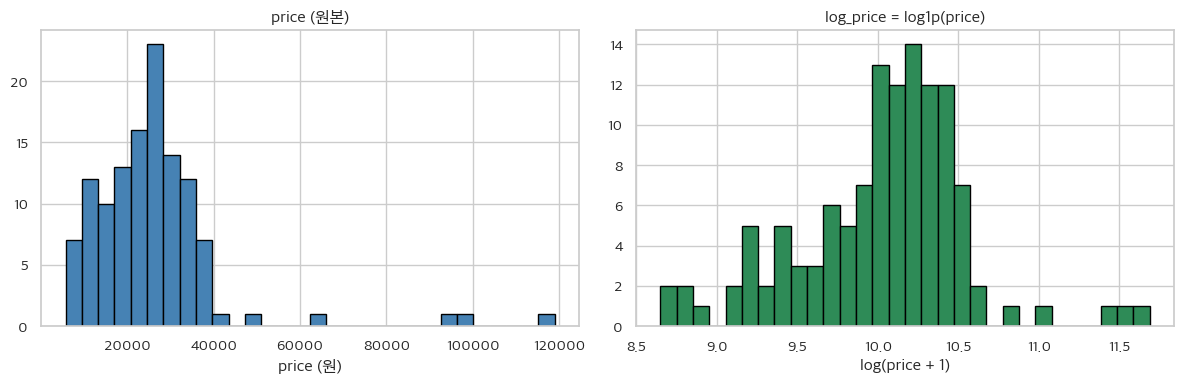

In [60]:
# 3.10.4-1. log_price 생성
from scipy.stats import skew

features['log_price'] = np.log1p(features['price'])

# 3.10.4-2. 검증 — describe 비교 + 왜도(skewness) 변화
print("=== price vs log_price describe ===")
print(features[['price', 'log_price']].describe().round(2))
print()
print("=== 왜도(skewness) 변화 ===")
print(f"price     skew: {skew(features['price']):.3f}    (양수 = 우측 꼬리, 0에 가까울수록 정규분포)")
print(f"log_price skew: {skew(features['log_price']):.3f}")
print()
print(f"features.shape: {features.shape}     # (120, 29) 기대 = 28 + 1")

# 3.10.4-3. 시각화 — 변환 전후 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(features['price'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('price (원본)')
axes[0].set_xlabel('price (원)')
axes[1].hist(features['log_price'], bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('log_price = log1p(price)')
axes[1].set_xlabel('log(price + 1)')
plt.tight_layout()
plt.show()


#### 3.10.5 `discount_rate` — 할인율 (%)

Section 1.4 결정: `(price_original - price) / price_original * 100`. `price_original` NULL(할인 정보 없음)이면 **0% 처리**.

해석:
- 0% = 정가 판매 (또는 할인 정보 미공개)
- 양수 % = 할인 진행 중

⚠️ 데이터 누수 우려는 낮음 — 크롤링 시점의 할인 상태는 상품 출시 시점의 가격 정책과 상관 있음. 다만 시점 정확도가 떨어질 수 있어 약한 시그널로 취급.


In [61]:
# 3.10.5-1. discount_rate 생성
features['discount_rate'] = np.where(
    features['price_original'].notna() & (features['price_original'] > 0),
    (features['price_original'] - features['price']) / features['price_original'] * 100,
    0.0
)

=== discount_rate describe ===
count    120.00
mean      24.12
std       12.50
min        0.00
25%       17.24
50%       24.85
75%       30.65
max       54.73
Name: discount_rate, dtype: float64

price_original NULL/0 상품 수: 6
  → 그중 discount_rate == 0 인 건수: 6

할인 없음 (0%):  6개 (5.0%)
할인 있음 (>0%): 114개 (95.0%)

features.shape: (120, 30)     # (120, 30) 기대 = 29 + 1


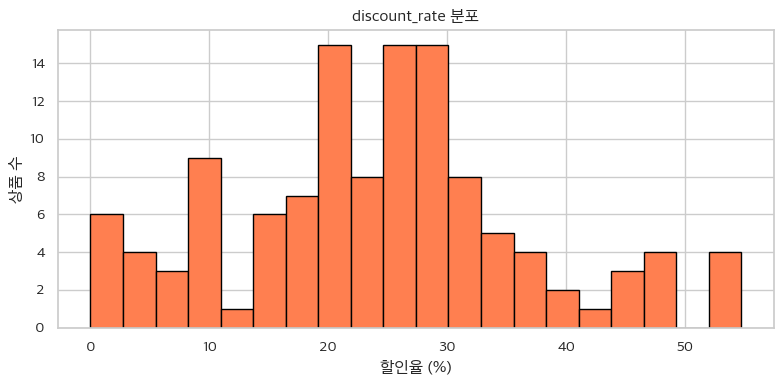

In [62]:
# 3.10.5-2. 검증 — describe + NULL 처리 확인
print("=== discount_rate describe ===")
print(features['discount_rate'].describe().round(2))
print()

# NULL → 0% 처리 검증
null_orig = features['price_original'].isna() | (features['price_original'] == 0)
print(f"price_original NULL/0 상품 수: {null_orig.sum()}")
print(f"  → 그중 discount_rate == 0 인 건수: {(features.loc[null_orig, 'discount_rate'] == 0).sum()}")
print()

# 할인 유무 분포
no_discount = (features['discount_rate'] == 0).sum()
has_discount = (features['discount_rate'] > 0).sum()
print(f"할인 없음 (0%):  {no_discount}개 ({no_discount/len(features)*100:.1f}%)")
print(f"할인 있음 (>0%): {has_discount}개 ({has_discount/len(features)*100:.1f}%)")
print()
print(f"features.shape: {features.shape}     # (120, 30) 기대 = 29 + 1")

# 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(features['discount_rate'], bins=20, color='coral', edgecolor='black')
ax.set_title('discount_rate 분포')
ax.set_xlabel('할인율 (%)')
ax.set_ylabel('상품 수')
plt.tight_layout()
plt.show()

---
## 4. 검증

### 4.1 NaN 점검

In [63]:
# 4.1 NaN 점검 — 각 피처별 NaN 개수 + 비율
nan_summary = pd.DataFrame({
    'NaN_count': features.isnull().sum(),
    'NaN_ratio_%': (features.isnull().sum() / len(features) * 100).round(2)
})
nan_cols = nan_summary[nan_summary['NaN_count'] > 0].sort_values('NaN_count', ascending=False)

if len(nan_cols) == 0:
    print("✅ 모든 피처에 NaN 없음 — 정상")
else:
    print(f"⚠️ NaN 발견: {len(nan_cols)}개 컬럼")
    print(nan_cols)
    print()
    print("→ 가능한 원인 (3주차 메모 기반):")
    print("  - rating_drift: 후반 7일에 리뷰 없는 상품 (분모 0)")
    print("  - skin_type_diversity: 피부타입 정보 없는 상품")
    print("  - velocity_slope: 14일 내 리뷰 1건 이하 (회귀 불가)")

print(f"\nfeatures.shape: {features.shape}")
print(f"전체 컬럼: {list(features.columns)}")

⚠️ NaN 발견: 10개 컬럼
                            NaN_count  NaN_ratio_%
rating_drift                       22        18.33
rating_2wk_std                     12        10.00
price_original                      6         5.00
reviews_2wk_velocity_slope          1         0.83
rating_2wk_mean                     1         0.83
photo_review_ratio_2wk              1         0.83
review_length_mean_2wk              1         0.83
review_burst_3d                     1         0.83
skin_type_diversity                 1         0.83
skin_type_n_unique                  1         0.83

→ 가능한 원인 (3주차 메모 기반):
  - rating_drift: 후반 7일에 리뷰 없는 상품 (분모 0)
  - skin_type_diversity: 피부타입 정보 없는 상품
  - velocity_slope: 14일 내 리뷰 1건 이하 (회귀 불가)

features.shape: (120, 30)
전체 컬럼: ['product_id', 'is_hit', 'category', 'launch_date_est', 'cutoff_date', 'reviews_2wk_count', 'reviews_2wk_velocity_slope', 'rating_2wk_mean', 'rating_2wk_std', 'photo_review_ratio_2wk', 'review_length_mean_2wk', 'rating_drift', 'review_burst_

In [64]:
# 4.1-2. NaN 패턴 진단 — 어떤 상품이 NaN을 만들었는지 추적
nan_per_row = features.isnull().sum(axis=1)
print("=== 행별 NaN 개수 분포 ===")
print(nan_per_row.value_counts().sort_index())
print()

# NaN 많은 상품 추출 (C그룹: 7컬럼이 동일 1상품인지 검증)
heavily_nan = features[nan_per_row >= 5]
print(f"NaN 5개 이상인 상품 수: {len(heavily_nan)}")
if len(heavily_nan) > 0:
    cols_show = ['product_id', 'reviews_2wk_count', 'is_hit', 'category_main', 'launch_date_est']
    print(heavily_nan[cols_show])
print()

# rating_drift NaN 가설: 후반 7일에 리뷰 0건 (즉 14일 내 리뷰가 적음)
print("=== rating_drift NaN 상품의 reviews_2wk_count 분포 ===")
print(features.loc[features['rating_drift'].isnull(), 'reviews_2wk_count'].describe().round(2))
print()

# rating_2wk_std NaN 가설: 리뷰 1건 → std 계산 불가
print("=== rating_2wk_std NaN 상품의 reviews_2wk_count 분포 ===")
print(features.loc[features['rating_2wk_std'].isnull(), 'reviews_2wk_count'].describe().round(2))

=== 행별 NaN 개수 분포 ===
0    92
1    16
2    11
9     1
Name: count, dtype: int64

NaN 5개 이상인 상품 수: 1
        product_id  reviews_2wk_count  is_hit category_main launch_date_est
108  A000000250214                  0       0          스킨케어      2026-03-01

=== rating_drift NaN 상품의 reviews_2wk_count 분포 ===
count     22.00
mean       6.36
std       20.99
min        0.00
25%        1.00
50%        1.00
75%        2.00
max      100.00
Name: reviews_2wk_count, dtype: float64

=== rating_2wk_std NaN 상품의 reviews_2wk_count 분포 ===
count    12.00
mean      0.92
std       0.29
min       0.00
25%       1.00
50%       1.00
75%       1.00
max       1.00
Name: reviews_2wk_count, dtype: float64


In [65]:
# 4.1-3. NaN 처리 (옵션 B: flag 컬럼 + 0 채우기)
#   Step 1: reviews_2wk_count=0 상품 1개 drop (분석 가설 적용 불가)
#   Step 2: has_drift_signal, has_std_signal flag 추가 (NaN 여부 자체를 피처화)
#   Step 3: rating_drift, rating_2wk_std NaN → 0 채우기
#   ※ price_original NaN 6개는 그대로 (검증용 원본, 4주차 학습 직전 drop)

# === Step 1: drop ===
before_rows = len(features)
features = features[features['reviews_2wk_count'] > 0].reset_index(drop=True)
print(f"Step 1: reviews_2wk_count=0 상품 drop → {before_rows} → {len(features)}행")

# === Step 2: flag 추가 ===
features['has_drift_signal'] = features['rating_drift'].notna().astype(int)
features['has_std_signal']   = features['rating_2wk_std'].notna().astype(int)
print(f"\nStep 2: flag 2개 추가")
print(f"  has_drift_signal=1 (시그널 있음): {features['has_drift_signal'].sum()} / {len(features)}  ({features['has_drift_signal'].mean()*100:.1f}%)")
print(f"  has_std_signal=1   (시그널 있음): {features['has_std_signal'].sum()} / {len(features)}  ({features['has_std_signal'].mean()*100:.1f}%)")

# === Step 3: NaN → 0 채우기 ===
print(f"\nStep 3: NaN → 0 채우기")
for col in ['rating_drift', 'rating_2wk_std']:
    n = features[col].isnull().sum()
    features[col] = features[col].fillna(0)
    print(f"  {col}: {n}개 → 0")

# === 검증 ===
print("\n=== NaN 처리 후 ===")
remaining = features.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("✅ 모든 NaN 처리 완료")
else:
    print("남은 NaN:")
    print(remaining)
    print("→ price_original은 검증·디버깅용 (4주차 학습 직전 drop 예정)")

print(f"\nfeatures.shape: {features.shape}     # (119, 32) 기대 = 30 - 1 + 2(flag) wait, 30 그대로 + 2 = 32")

Step 1: reviews_2wk_count=0 상품 drop → 120 → 119행

Step 2: flag 2개 추가
  has_drift_signal=1 (시그널 있음): 98 / 119  (82.4%)
  has_std_signal=1   (시그널 있음): 108 / 119  (90.8%)

Step 3: NaN → 0 채우기
  rating_drift: 21개 → 0
  rating_2wk_std: 11개 → 0

=== NaN 처리 후 ===
남은 NaN:
price_original    6
dtype: int64
→ price_original은 검증·디버깅용 (4주차 학습 직전 drop 예정)

features.shape: (119, 32)     # (119, 32) 기대 = 30 - 1 + 2(flag) wait, 30 그대로 + 2 = 32


### 4.2 히트 vs 논히트 그룹 비교

In [66]:
# 4.2 hit vs non-hit 그룹 비교
compare_cols = [
    # 9개 핵심 피처
    'reviews_2wk_count', 'reviews_2wk_velocity_slope',
    'rating_2wk_mean', 'rating_2wk_std',
    'photo_review_ratio_2wk', 'review_length_mean_2wk',
    'rating_drift', 'review_burst_3d',
    'skin_type_diversity', 'skin_type_n_unique',
    # 메타 5개
    'is_makeup', 'brand_freq', 'log_price', 'discount_rate',
    # flag 2개
    'has_drift_signal', 'has_std_signal',
]

# === 표 1: 평균 비교 (effect_size 큰 순) ===
mean_table = features.groupby('is_hit')[compare_cols].mean().T
mean_table.columns = ['non_hit_mean', 'hit_mean']
mean_table['diff'] = mean_table['hit_mean'] - mean_table['non_hit_mean']
mean_table['effect_size'] = mean_table['diff'] / features[compare_cols].std()  # 정규화 차이
mean_table = mean_table.reindex(mean_table['effect_size'].abs().sort_values(ascending=False).index)

print("=== 표 1: hit vs non-hit 평균 비교 (effect_size 절댓값 큰 순) ===")
print("effect_size: (hit_mean - non_hit_mean) / 전체std. 절댓값 0.3↑이면 의미 있는 차이")
print(mean_table.round(3))

# === 표 2: 분산 가설 검증 ===
std_table = features.groupby('is_hit')[compare_cols].std().T
std_table.columns = ['non_hit_std', 'hit_std']
std_table['std_ratio'] = std_table['hit_std'] / std_table['non_hit_std']
std_table = std_table.sort_values('std_ratio', ascending=False)

print("\n=== 표 2: 분산 가설 검증 — std_ratio (hit / non_hit) ===")
print("ratio > 1 = hit 그룹 분산이 더 큼 = 분산 가설 지지")
print(std_table.round(3))

# === 표본 크기 ===
print(f"\n=== 표본 크기 ===")
print(features['is_hit'].value_counts())

=== 표 1: hit vs non-hit 평균 비교 (effect_size 절댓값 큰 순) ===
effect_size: (hit_mean - non_hit_mean) / 전체std. 절댓값 0.3↑이면 의미 있는 차이
                            non_hit_mean  hit_mean    diff  effect_size
photo_review_ratio_2wk             0.895     0.778  -0.117       -0.530
review_length_mean_2wk           239.610   193.390 -46.220       -0.340
rating_2wk_std                     0.362     0.528   0.165        0.325
rating_drift                       0.043    -0.109  -0.152       -0.320
discount_rate                     22.067    25.920   3.853        0.308
rating_2wk_mean                    4.801     4.673  -0.129       -0.237
reviews_2wk_count                 17.356    19.883   2.527        0.129
review_burst_3d                    8.153     9.567   1.414        0.127
skin_type_diversity                1.709     1.646  -0.063       -0.081
has_std_signal                     0.898     0.917   0.018        0.063
skin_type_n_unique                 4.492     4.383  -0.108       -0.054
brand_freq  

### 4.3 분포 시각화 (선택, 1~2장)

/var/folders/65/xgrfhqb5421c768r34jn92f40000gn/T/ipykernel_45523/3434466226.py:27: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Apple SD Gothic Neo.
  plt.tight_layout()
/var/folders/65/xgrfhqb5421c768r34jn92f40000gn/T/ipykernel_45523/3434466226.py:28: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Apple SD Gothic Neo.
  plt.savefig('../reports/figures/feature_overview.png', dpi=150, bbox_inches='tight')
/Users/gimgyumin/Desktop/Developer/데이터 분석/oliveyoung-hit-prediction/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Apple SD Gothic Neo.
  fig.canvas.print_figure(bytes_io, **kw)


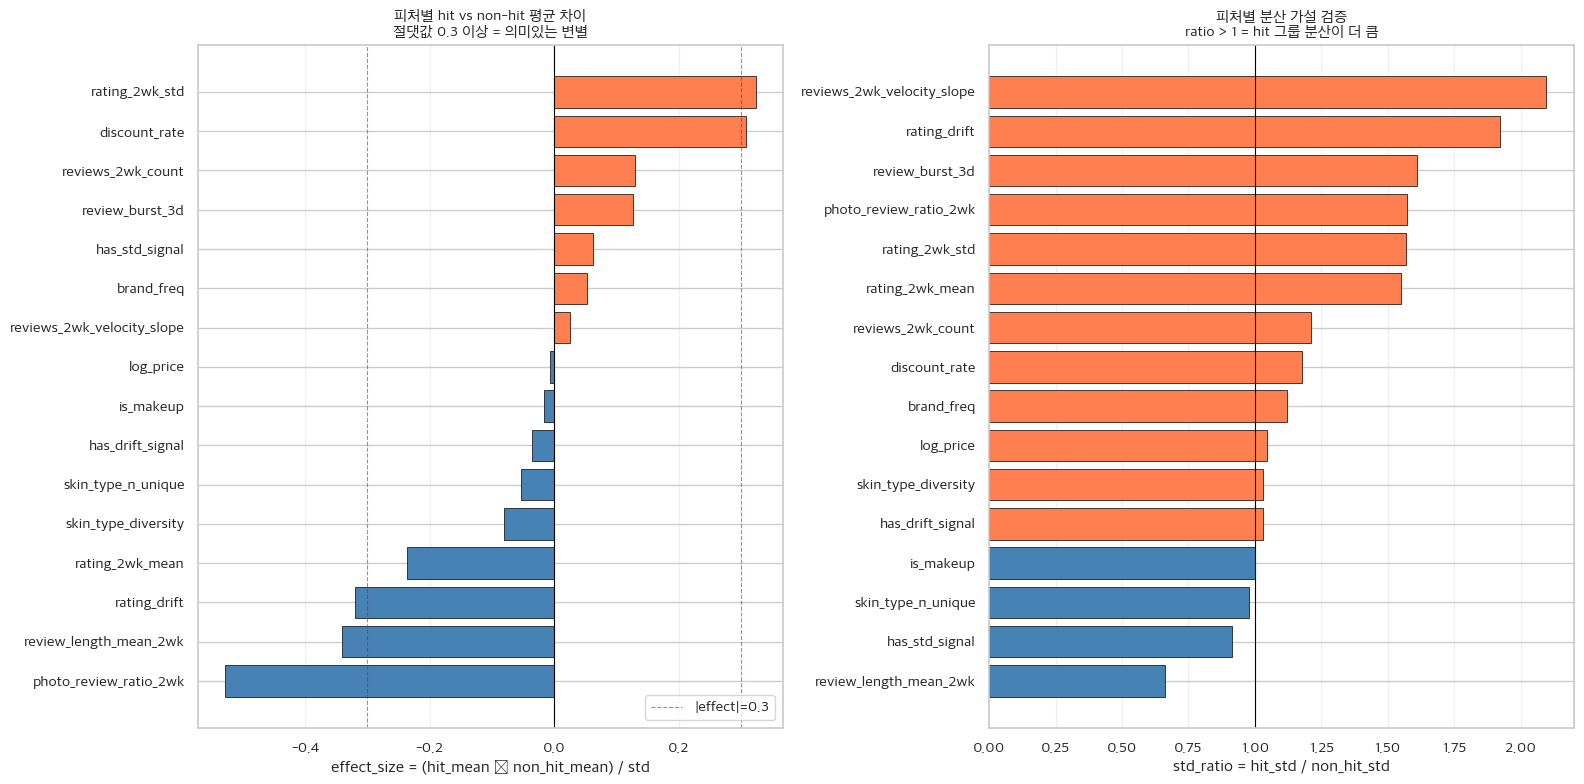

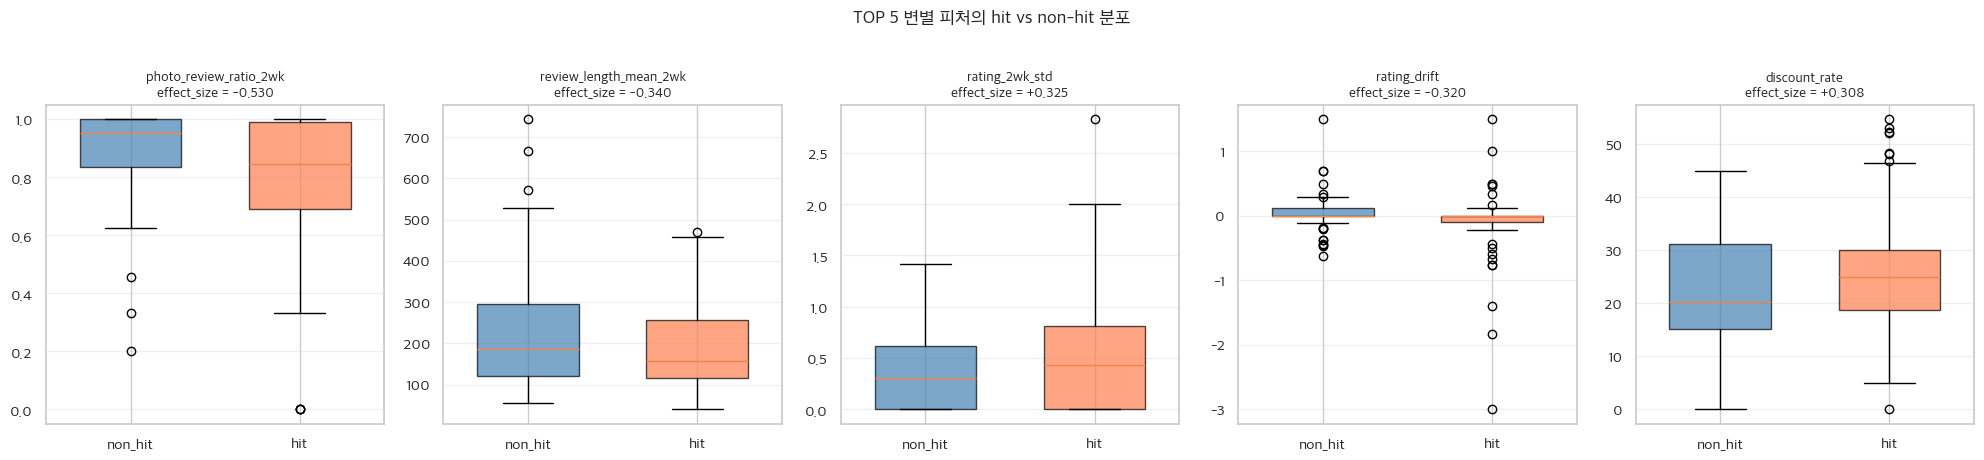

✅ 시각화 저장 완료:
  - reports/figures/feature_overview.png
  - reports/figures/top5_boxplot.png


In [67]:
# 4.3 시각화 — Figure 1: 종합 막대 / Figure 2: TOP 5 boxplot

# === Figure 1: 종합 막대 (effect_size + std_ratio) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1-1. effect_size 막대
es_sorted = mean_table['effect_size'].sort_values()
colors_es = ['steelblue' if v < 0 else 'coral' for v in es_sorted]
axes[0].barh(es_sorted.index, es_sorted.values, color=colors_es, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].axvline(0.3, color='red', ls='--', lw=0.8, alpha=0.6, label='|effect|=0.3')
axes[0].axvline(-0.3, color='red', ls='--', lw=0.8, alpha=0.6)
axes[0].set_xlabel('effect_size = (hit_mean − non_hit_mean) / std')
axes[0].set_title('피처별 hit vs non-hit 평균 차이\n절댓값 0.3 이상 = 의미있는 변별', fontsize=11)
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3, axis='x')

# 1-2. std_ratio 막대
sr_sorted = std_table['std_ratio'].sort_values()
colors_sr = ['steelblue' if v < 1 else 'coral' for v in sr_sorted]
axes[1].barh(sr_sorted.index, sr_sorted.values, color=colors_sr, edgecolor='black', linewidth=0.5)
axes[1].axvline(1, color='black', lw=0.8)
axes[1].set_xlabel('std_ratio = hit_std / non_hit_std')
axes[1].set_title('피처별 분산 가설 검증\nratio > 1 = hit 그룹 분산이 더 큼', fontsize=11)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/figures/feature_overview.png', dpi=150, bbox_inches='tight')
plt.show()


# === Figure 2: TOP 5 effect_size 피처 boxplot ===
top5 = mean_table['effect_size'].abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, col in zip(axes, top5):
    data_nonhit = features.loc[features['is_hit'] == 0, col]
    data_hit = features.loc[features['is_hit'] == 1, col]
    bp = ax.boxplot([data_nonhit, data_hit], tick_labels=['non_hit', 'hit'],
                    patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('coral')
    bp['boxes'][1].set_alpha(0.7)
    es = mean_table.loc[col, 'effect_size']
    ax.set_title(f"{col}\neffect_size = {es:+.3f}", fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('TOP 5 변별 피처의 hit vs non-hit 분포', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/top5_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 시각화 저장 완료:")
print("  - reports/figures/feature_overview.png")
print("  - reports/figures/top5_boxplot.png")

---
## 5. 결과 저장

> 5주차 모델링에서 입력으로 사용할 피처 매트릭스 저장.

In [68]:
# 5. features 저장 — parquet (모델용) + CSV (검증용)
# price_original은 검증·디버깅용으로 유지 (4주차 학습 직전 drop)

from pathlib import Path

out_dir = Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)

parquet_path = out_dir / 'features.parquet'
csv_path     = out_dir / 'features.csv'

features.to_parquet(parquet_path, index=False)
features.to_csv(csv_path, index=False, encoding='utf-8-sig')  # 한글 깨짐 방지

# 검증 — 파일 크기 + 재로딩 확인
parquet_size_kb = parquet_path.stat().st_size / 1024
csv_size_kb     = csv_path.stat().st_size / 1024

print(f"✅ 저장 완료")
print(f"  - {parquet_path}  ({parquet_size_kb:.1f} KB)")
print(f"  - {csv_path}      ({csv_size_kb:.1f} KB)")
print()
print(f"shape: {features.shape}")
print(f"컬럼 수: {len(features.columns)}")

# 재로딩 검증 (parquet)
reloaded = pd.read_parquet(parquet_path)
assert reloaded.shape == features.shape, "shape 불일치"
assert (reloaded.columns == features.columns).all(), "컬럼 불일치"
print("\n✅ parquet 재로딩 검증 통과 (shape + 컬럼 일치)")

✅ 저장 완료
  - ../data/processed/features.parquet  (31.3 KB)
  - ../data/processed/features.csv      (33.1 KB)

shape: (119, 32)
컬럼 수: 32

✅ parquet 재로딩 검증 통과 (shape + 컬럼 일치)


---
## 6. 3주차 요약 & 다음 단계

### 6.1 한 일

- **9개 핵심 피처 + 5개 메타 피처 + 2개 flag** = 총 16개 변별 피처를 정의·구현했다. (`features.parquet` 119 × 32)
  - 핵심 9개: 리뷰 수·속도(2), 평점 평균·분산·드리프트(3), 포토 비율, 길이, burst, skin_type 다양성
  - 메타 5개: `is_makeup`, `category_sub_group` 더미 5개, `brand_freq`, `log_price`, `discount_rate`
  - flag 2개: `has_drift_signal`, `has_std_signal` — NaN 자체를 정보로 활용
- **NaN 진단 → 옵션 B 처리** (1상품 drop + flag 추가 + 0 채우기). 119행 × 32컬럼 확보.
- **hit vs non-hit 정량 비교**: `effect_size`(평균 차이)와 `std_ratio`(분산 비율) 두 축으로 16개 피처 분석.
- **시각화 2장 산출**: `reports/figures/feature_overview.png`(전체 요약), `top5_boxplot.png`(상위 5개 drill-down).
- `features.parquet` + `features.csv` 저장 → 4주차 모델링 입력 준비 완료.

### 6.2 발견점·결정

**🎯 핵심 가설 — "히트 상품 = evangelist → 대중 확산" 가설**

TOP 5 변별 피처 중 **반직관적 3개**가 하나의 일관된 그림을 그렸다:

| 피처 | 방향 | 해석 |
|---|---|---|
| `photo_review_ratio_2wk` | hit이 낮음 (-0.53) | non-hit은 거의 100% 사진 리뷰, hit은 사진 없는 리뷰도 섞임 |
| `review_length_mean_2wk` | hit이 짧음 (-0.34) | hit은 짧고 균질, non-hit은 길고 들쭉날쭉 (양극 분포) |
| `rating_drift`           | hit이 음수 (-0.32) | hit은 시간 갈수록 평점 하락 |

→ **"히트 상품은 초기 evangelist의 폭발적 반응 후 일반 대중이 빠르게 유입되어 evangelist 패턴(긴 리뷰·사진·고평점)이 희석된다"** 라는 단일 가설로 설명 가능. 5주차 텍스트 분석에서 이 가설을 토픽 분포로 검증할 거리.

**🔢 분산 가설 확장 검증 성공**

- 3주차 1차 검증: 9개 중 8개 일관 (1예외)
- 3주차 2차 검증 (16개로 확장): **13개가 `std_ratio > 1`** → 가설 일관성 유지
- 가장 강한 지지: `velocity_slope` (ratio 2.10), `rating_drift` (1.92), `review_burst_3d` (1.61)
- 유일한 명확한 반례: `review_length_mean_2wk` (ratio 0.66) — 위 "균질 리뷰" 가설과 정합

**⚙️ 의사결정 기록**

- **NaN 처리**: 옵션 B(flag + 0). 단순 0 채우기보다 "정보 없음"을 모델이 구분 가능하게.  
  단, 4.2 결과 flag effect_size가 |0.07| 미만 → 4주차 SHAP=0 확인되면 정당하게 drop.
- **`price_original` NULL 6개 → 0%**: 보수적 변환. 면접 시 "별도 `has_discount_info` 플래그가 더 정확했을 수 있음" 인정.
- **저장 형식 parquet + CSV 병행**: parquet은 4주차 모델 빠른 로드용, CSV는 검증·면접 시연용.
- **표본 균형 확인**: hit=60, non_hit=59 → class_weight 조정 불필요.

### 6.3 다음 단계 (4주차)

**🎯 4주차 목표: 베이스라인 로지스틱 회귀 + SHAP 해석** (`notebooks/03_modeling.ipynb`)

1. **데이터 분할**: stratified train/test split (test 20%, random_state 고정)
2. **전처리**: 학습 직전 `price`, `price_original`, `category_main`, `category_sub`, `brand`, `category_sub_group`, `product_id`, `launch_date_est`, `cutoff_date` drop. 수치형 16개 + 더미 5개 → 학습 매트릭스.
3. **표준화**: `StandardScaler` (로지스틱 회귀 계수 해석 위해)
4. **모델 학습**: `LogisticRegression(class_weight=None)` (균형 표본이므로)
5. **성능 측정**: ROC-AUC, Precision/Recall, Confusion Matrix
6. **해석**: 계수 + SHAP value로 "가설 검증 표" 작성  
   → 분산 가설·반직관 3개·flag 컬럼이 진짜 모델에 기여하는지 정량 확인
7. **에러 분석**: 오분류된 상품 manual 확인 → 4주차 회고 정리

**🚀 5주차 결정은 4주차 결과에 따라 미룸**

- 베이스라인 AUC > 0.80 → 키워드 빈도 또는 감성 분석으로 가볍게 보강
- AUC < 0.75 → BERTopic 토픽 모델링으로 정성적 인사이트 추가
- → 어느 쪽이든 *"수치 모델 + 텍스트 피처"* 합쳐 성능 비교 ("텍스트 추가로 AUC +X%" 스토리)